Load in data to analyse:

In [6]:
import pandas as pd
import numpy as np
import os
import chromatin_tracing_python.image_processing_functions as ip
import chromatin_tracing_python.trace_analysis_functions as tr

config = ip.load_config(r'20200604_Exp328v2_KSB_Elyra_tracing_myc_D1-10_config.yaml')
traces = pd.read_csv(r'20200604_Exp328v2_KSB_Elyra_tracing_myc_D1-10_traces.csv')

Apply quality control metrics from config file and some manually observed poor quality traces. Also filter by length so only the more complete traces are included.

In [2]:
traces_qc = traces.copy()
traces_qc['QC'] = traces.apply(tr.tracing_qc, axis=1, args=(config,))
traces_qc['frame_name'] = traces_qc.apply(lambda row: config['frame_name'][row['frame']], axis=1)

In [3]:
exclude_frame = ['blank', 'all', 'pre_image', 'E01_rep']
exclude_trace = [15, 102, 105, 142, 144]
traces_qc['QC'][traces_qc['frame_name'].isin(exclude_frame)] = 0
traces_qc['QC'][traces_qc['trace_ID'].isin(exclude_trace)] = 0
traces_long = tr.tracing_length_qc(traces_qc, min_length=8)

Plot single trace:

In [4]:
tr.plot_traces(traces_long.query('QC == 1'),[5])

['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08', 'E09', 'E10']


Further, we can calculate pairwise distance matrixes for the traces, and we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and metrics of similarity between the two traces. These are the mse and pcc of the alignment, and the mse of the two pair-wise distance matrices, as well as the mse and pcc coefficient between the PWDs.

In [6]:
pwds = tr.pwd_calc(traces_long)
pairs = tr.trace_analysis(traces_long, pwds)

We can use the paired similarity values to group the traces. We can use any of the similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace. Set the color_threshold to a value higher than the largest difference to simply make a group of all traces for later analysis.

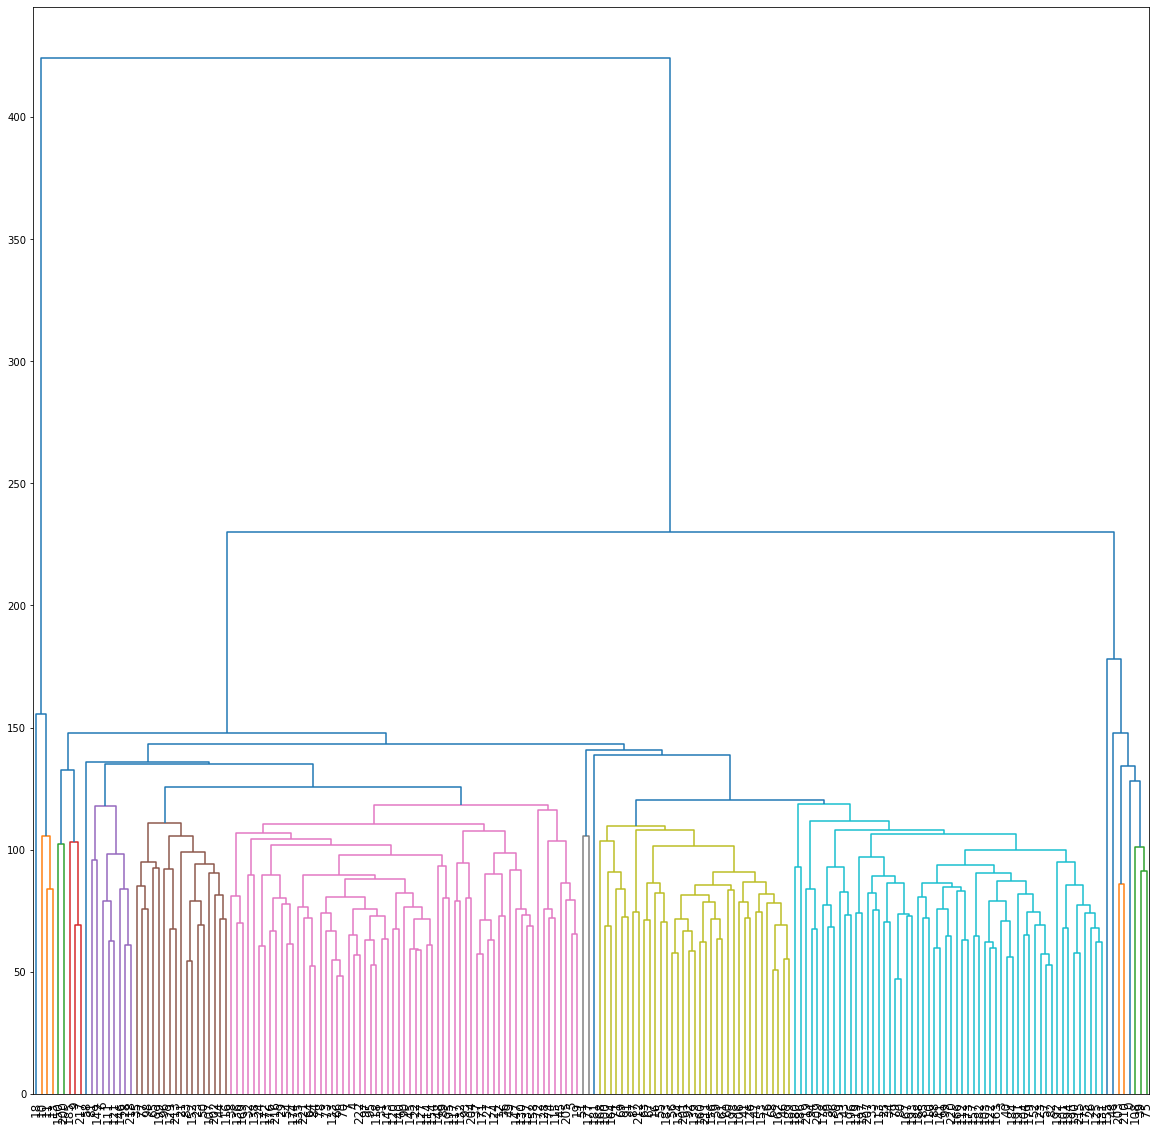

In [7]:
cluster_df = tr.trace_clustering(pairs, metric='aligned_mse', method='average', color_threshold=120)

In [11]:
cluster_id = 6
cluster_members = cluster_df[cluster_df['cluster']==cluster_id]['trace_ID'].values
print(cluster_members)

[ 21  23  35  44  50  65  77  83  96  98 107 116 129 152 199 202 213]


In [17]:
clust_aligned, clust_mean = tr.general_procrustes_analysis(traces_long, cluster_members)
tr.plot_gpa_output(clust_aligned, clust_mean, cluster_members)

Initial distance is 1597.1453034995916
GPA converged after 4 cycles with distance 750.6421434420812
[ 1  2  3  4  5  6  7  8  9 10]


In [14]:
aligned_all_gpa=tr.run_gpa_all_clusters(traces_long, cluster_df, min_cluster=4)
tr.plot_multi_points(aligned_all_gpa)

[[6, 28, 81, 111, 121, 146, 149, 218], [21, 23, 35, 44, 50, 65, 77, 83, 96, 98, 107, 116, 129, 152, 199, 202, 213], [4, 5, 7, 12, 19, 22, 24, 27, 29, 31, 32, 36, 37, 38, 45, 49, 54, 64, 66, 70, 72, 73, 74, 78, 84, 89, 90, 93, 95, 97, 114, 115, 117, 118, 120, 124, 127, 128, 130, 132, 133, 135, 136, 137, 138, 140, 143, 145, 147, 148, 154, 158, 169, 171, 172, 174, 176, 195, 204, 205, 216, 221, 222], [16, 41, 46, 47, 55, 56, 59, 60, 63, 67, 68, 69, 71, 76, 87, 91, 92, 100, 106, 126, 134, 139, 153, 156, 160, 161, 162, 164, 168, 183, 189, 198, 201, 211, 212], [3, 25, 26, 30, 33, 34, 40, 43, 52, 57, 79, 80, 82, 85, 86, 88, 94, 99, 101, 103, 104, 110, 112, 113, 119, 122, 123, 125, 131, 141, 157, 159, 163, 166, 167, 173, 175, 178, 179, 180, 182, 184, 186, 188, 190, 191, 192, 193, 194, 196, 197, 207, 209, 215, 219, 220]]
Initial distance is 732.8538421687737
GPA converged after 4 cycles with distance 286.899445511646
Initial distance is 1687.9257402814117
GPA converged after 7 cycles with distan

In [18]:
tr.radius_of_gyration(clust_mean)

208.32141907457094

In [19]:
tr.elongation(clust_mean)

Eigenvalues are  [12411.52392365  1824.78941698   229.62454112]


0.8529761995222103

In [21]:
import plotly.express as px
all_trace_ids = list(traces_long['trace_ID'].unique())
px.bar(x=all_trace_ids, y = [tr.radius_of_gyration(points) for points in tr.points_from_traces(traces_long, all_trace_ids)])

In [22]:
px.bar(x=all_trace_ids, y=[tr.elongation(points) for points in tr.points_from_traces(traces_long, all_trace_ids)])

Eigenvalues are  [3089.14290897  863.62790687  426.2098605 ]
Eigenvalues are  [5810.25031834 3499.87282624 1208.05379689]
Eigenvalues are  [5345.52199491 1944.32880462  602.84319644]
Eigenvalues are  [14820.89888147  4150.60888194   724.52302936]
Eigenvalues are  [20865.00594004  4159.79621133  1934.46382676]
Eigenvalues are  [7497.82127756 4393.96518302  665.9809172 ]
Eigenvalues are  [19106.53260549  8748.54370951  1137.99931891]
Eigenvalues are  [14329.78075188  1217.98740358   974.34829709]
Eigenvalues are  [6084.08740468 1440.82111495  721.33878032]
Eigenvalues are  [5123.35102147 3143.12691703  977.73237704]
Eigenvalues are  [4770.36866379 2257.55811761 1856.11173122]
Eigenvalues are  [14437.709434    5305.4682246    933.14486833]
Eigenvalues are  [10803.3516615   3957.21264741   613.75811393]
Eigenvalues are  [14103.22566206  1875.3228386    905.96323117]
Eigenvalues are  [9483.90624476 4835.50650689 2410.62002112]
Eigenvalues are  [6604.61981963 2005.93827204  974.41121769]
Eig